# 02 — Feature Engineering

Derive the 5 ML-ready features from cleaned keystroke data.

In [12]:
import pandas as pd
import numpy as np

df=pd.read_csv('C:\\كتب لازم اخلصها عشان ابقى عالم بيانات\\subl\\subl-main\\subl-main\\data & ai by ElDeep\\mindtype-ai\\data\\processed\\final_features.csv')

In [13]:
df.drop('userId',axis=1,inplace=True)

## Now we should map bc Random forest doesn't understand Text

In [14]:
df['typistType']=df['typistType'].map({'Touch Typist':1,'Two Finger Typist':1,'One Finger Typist':2})

In [15]:
df['pcTimeAverage']=df['pcTimeAverage'].map({'less than an hour per day':1,'between 1 hour and 3 hours per day':1,'More than 3 hours per day':2})

In [16]:
# low Cortisol >> 0
# optimal Cortisol >> 1
# high Cortisol >> 2
stress_mapping = {
    'C': 0,
    'N': 1,
    'H': 1,
    'S': 2,
    'A': 2
}
df['stress_Level'] = df['emotionIndex'].map(stress_mapping)

In [17]:
df.drop('emotionIndex',axis=1,inplace=True)  

In [18]:
df['gender']=df['gender'].map({'Female':1,'Male':0})

In [19]:
df['ageRange']=df['ageRange'].map({'>=50':0,'16-19':1,'30-39':2,'20-29':3}) # here I will map them according to how much each age category is stressed

## نحاول نعمل توازن اكتر بين انواع الكاتبين بحيث ميكونش فيه تحيز

In [20]:
# 1. تضخيم عدد الحروف بناءً على المهارة
df['balanced_n_keys'] = df['n_keys'] * df['typistType']

# 2. تضخيم الوقت المستغرق (عشان المبتدئ بياخد وقت أطول طبيعي)
df['balanced_tot_time'] = df['mean_tot_time'] * df['typistType']

# 3. تعديل وتيرة المسح (Deletion Frequency)
# لو المبتدئ مسح قليل، نضربه في المعامل عشان يبان إنه "دقيق جداً" بالنسبة لمهارته
df['balanced_del_freq'] = df['mean_del_freq'] * df['typistType']

In [21]:
df.head()

,mean_dwell,std_dwell,mean_flight,std_flight,median_flight,cv_flight,n_keys,mean_del_freq,mean_left_freq,mean_tot_time,typistType,pcTimeAverage,ageRange,gender,stress_Level,balanced_n_keys,balanced_tot_time,balanced_del_freq
0,97.875000,24.884007,476.070652,1251.961556,204.0,2.292415,184,NaN,NaN,NaN,2,1,3,1,1,368,NaN,NaN
1,155.913531,63.725533,472.388889,565.554156,334.0,1.197222,126,2.5,0.0,59665.0,1,1,3,0,1,126,59665.0,2.5
2,152.437500,38.561029,454.835938,1145.133357,238.5,2.292415,256,25.5,0.0,119528.0,1,1,3,0,1,256,119528.0,25.5
3,75.289474,50.484156,471.543860,498.214922,317.0,1.056561,114,0.5,0.0,53846.0,1,2,3,1,1,114,53846.0,0.5
4,71.820000,30.600647,411.040000,340.737492,298.0,0.828964,200,19.5,0.0,82270.0,1,2,3,1,1,200,82270.0,19.5


## evaluation

### نتائج أداء النموذج
- Accuracy: 0.9355
- Precision: 1.00 (class 0), 0.92 (class 1), 0.94 (class 2)
- Recall: 0.67 (class 0), 1.00 (class 1), 0.94 (class 2)
- F1-score: 0.80 (class 0), 0.96 (class 1), 0.94 (class 2)

### المتوسطات
- Macro avg: precision 0.96, recall 0.87, f1-score 0.90
- Weighted avg: precision 0.94, recall 0.94, f1-score 0.93

> الموديل يعطي نتائج قوية بشكل عام، لكن يجب الانتباه إلى الفئة 0 لأن دعمها (support) منخفض (9 عينات) مما يجعل دقة التنبؤ بها أقل استقرارًا.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
# 
# 1. تحديد الميزات (X) والهدف (y)
features = [
    'mean_dwell', 'std_dwell', 'mean_flight', 'std_flight', 'median_flight',
    'cv_flight',  'mean_del_freq','n_keys', 'mean_left_freq',
    'mean_tot_time', 'typistType', 'pcTimeAverage', 'ageRange', 'gender'
]

X = df[features]
y = df['stress_Level']

# 2. تقسيم البيانات (Train-Test Split)
# استخدمنا stratify لضمان توزيع مستويات الكورتيزول بالتساوي في التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. بناء وتدريب موديل الغابة العشوائية
# حددنا max_depth لمنع الحفظ الصم (Overfitting) اللي كان بيوصل لـ 93%
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced', 
    random_state=42
)

model.fit(X_train, y_train)

# 4. التنبؤ وتقييم الأداء
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9354838709677419
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         9
           1       0.92      1.00      0.96        35
           2       0.94      0.94      0.94        18

    accuracy                           0.94        62
   macro avg       0.96      0.87      0.90        62
weighted avg       0.94      0.94      0.93        62



## نتاكد انه شغال بذكاء مش بحفظ 

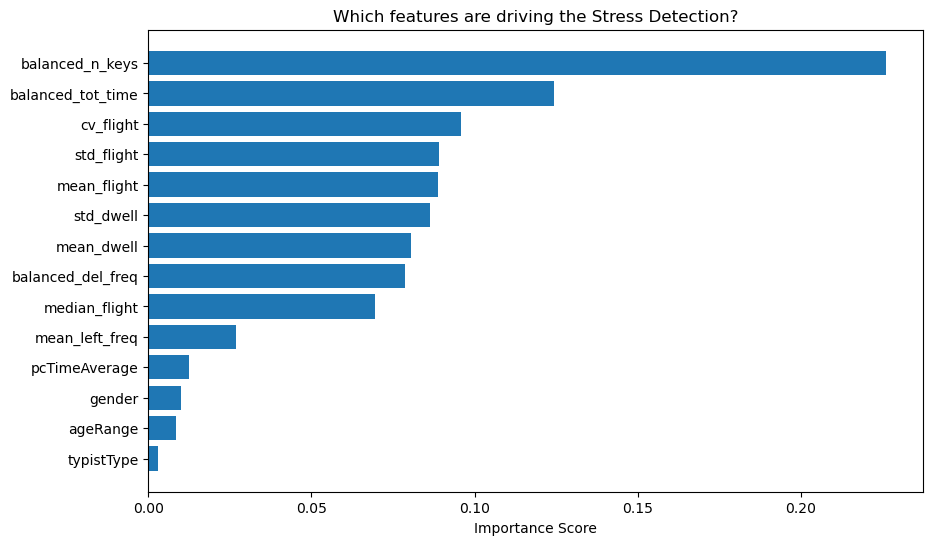

              Feature  Importance
7     balanced_n_keys    0.226226
9   balanced_tot_time    0.124210
5           cv_flight    0.095677
3          std_flight    0.089003
2         mean_flight    0.088741
1           std_dwell    0.086358
0          mean_dwell    0.080588
6   balanced_del_freq    0.078660
4       median_flight    0.069568
8      mean_left_freq    0.026935
11      pcTimeAverage    0.012547
13             gender    0.009926
12           ageRange    0.008601
10         typistType    0.002962


In [23]:
import matplotlib.pyplot as plt
import pandas as pd
features = [
    'mean_dwell', 'std_dwell', 'mean_flight', 'std_flight', 'median_flight',
    'cv_flight', 'balanced_del_freq', 'balanced_n_keys', 'mean_left_freq',
    'balanced_tot_time', 'typistType', 'pcTimeAverage', 'ageRange', 'gender'
]
# استخراج الأهمية
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# رسم بياني بسيط
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Which features are driving the Stress Detection?')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance_df)

## طيب خلينا نجرب من غير n_keys feature عشان نشوف هو بيحفظ ولا لا لو الدقة فوق 80 يبقى هو بيفهم مش بيحفظ 

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
# 
# 1. تحديد الميزات (X) والهدف (y)
features = [
    'mean_dwell', 'std_dwell', 'mean_flight', 'std_flight', 'median_flight',
    'cv_flight',  'mean_del_freq', 'mean_left_freq',
    'mean_tot_time', 'typistType', 'pcTimeAverage', 'ageRange', 'gender'
]

X = df[features]
y = df['stress_Level']

# 2. تقسيم البيانات (Train-Test Split)
# استخدمنا stratify لضمان توزيع مستويات الكورتيزول بالتساوي في التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. بناء وتدريب موديل الغابة العشوائية
# حددنا max_depth لمنع الحفظ الصم (Overfitting) اللي كان بيوصل لـ 93%
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced', 
    random_state=42
)

model.fit(X_train, y_train)

# 4. التنبؤ وتقييم الأداء
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8709677419354839
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         9
           1       0.87      0.94      0.90        35
           2       0.83      0.83      0.83        18

    accuracy                           0.87        62
   macro avg       0.90      0.81      0.85        62
weighted avg       0.88      0.87      0.87        62



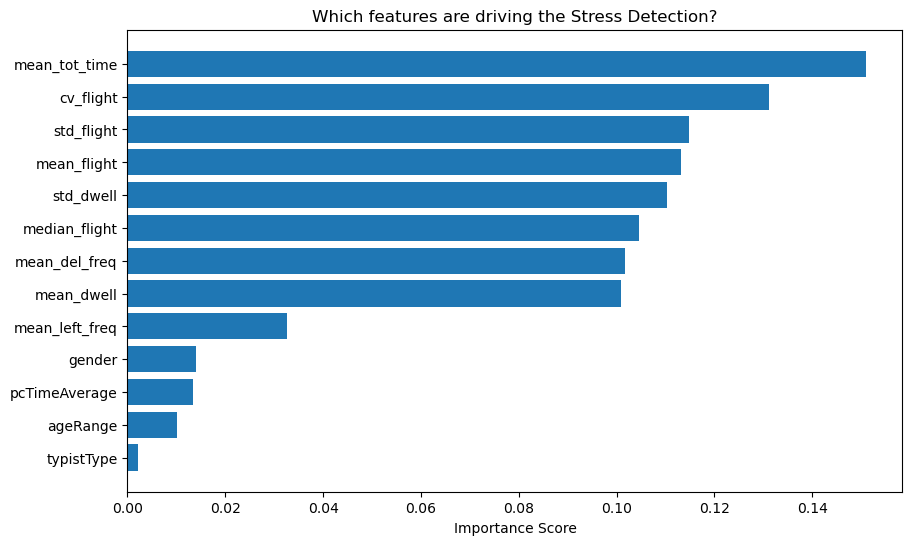

           Feature  Importance
8    mean_tot_time    0.150888
5        cv_flight    0.131211
3       std_flight    0.114859
2      mean_flight    0.113092
1        std_dwell    0.110272
4    median_flight    0.104581
6    mean_del_freq    0.101796
0       mean_dwell    0.100989
7   mean_left_freq    0.032606
12          gender    0.013945
10   pcTimeAverage    0.013436
11        ageRange    0.010134
9       typistType    0.002192


In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# استخراج الأهمية
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# رسم بياني بسيط
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Which features are driving the Stress Detection?')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance_df)

Accuracy: 0.9354838709677419
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         9
           1       0.92      1.00      0.96        35
           2       0.94      0.94      0.94        18

    accuracy                           0.94        62
   macro avg       0.96      0.87      0.90        62
weighted avg       0.94      0.94      0.93        62



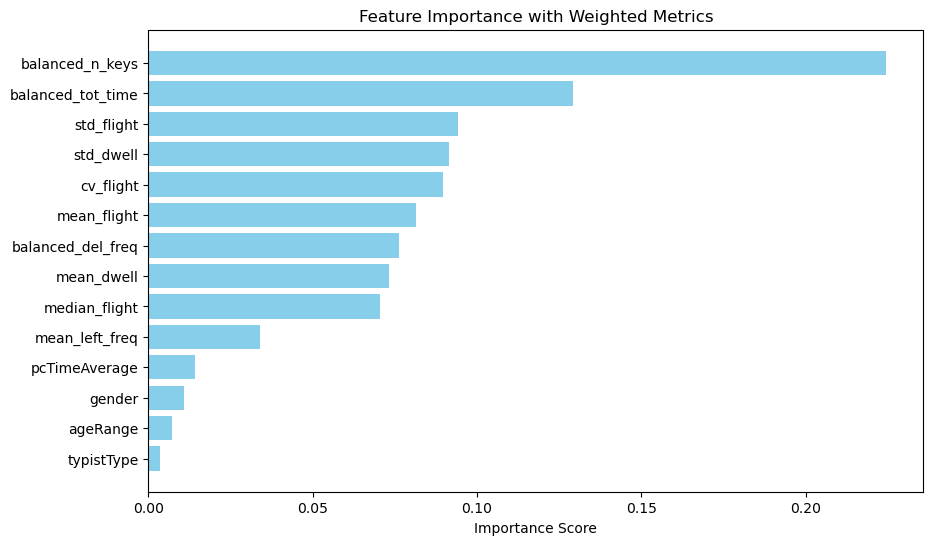

              Feature  Importance
7     balanced_n_keys    0.224507
9   balanced_tot_time    0.129215
3          std_flight    0.094107
1           std_dwell    0.091399
5           cv_flight    0.089595
2         mean_flight    0.081348
6   balanced_del_freq    0.076259
0          mean_dwell    0.073249
4       median_flight    0.070424
8      mean_left_freq    0.033964
11      pcTimeAverage    0.014301
13             gender    0.010929
12           ageRange    0.007083
10         typistType    0.003619


In [26]:
features = [
    'mean_dwell', 'std_dwell', 'mean_flight', 'std_flight', 'median_flight',
    'cv_flight', 'balanced_del_freq', 'balanced_n_keys', 'mean_left_freq',
    'balanced_tot_time', 'typistType', 'pcTimeAverage', 'ageRange', 'gender'
]

X = df[features]
y = df['stress_Level']

# 3. تقسيم البيانات (Train-Test Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. بناء وتدريب موديل الغابة العشوائية
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced', 
    random_state=42
)

model.fit(X_train, y_train)

# 5. التنبؤ وتقييم الأداء
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

# 6. استخراج أهمية الميزات (Feature Importance)
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# رسم بياني
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance with Weighted Metrics')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance_df)

In [27]:
import pickle
from pathlib import Path

# Save the trained model and feature contract for later reuse
artifact_dir = Path("model")
artifact_dir.mkdir(parents=True, exist_ok=True)
model_path = artifact_dir / "stress_model.pkl"

artifact = {
    "model": model,
    "feature_names": features,
}

with open(model_path, "wb") as f:
    pickle.dump(artifact, f)

print(f"Saved model artifact to: {model_path}")
print("Saved features:", artifact["feature_names"])


Saved model artifact to: model\stress_model.pkl
Saved features: ['mean_dwell', 'std_dwell', 'mean_flight', 'std_flight', 'median_flight', 'cv_flight', 'balanced_del_freq', 'balanced_n_keys', 'mean_left_freq', 'balanced_tot_time', 'typistType', 'pcTimeAverage', 'ageRange', 'gender']
